In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import mplniw.utils as ut
import cmocean

In [2]:
root_dir = '/Users/zcasparcohen/codes/NIW/data/'
ds = xr.open_dataset(root_dir+'niskine_mooring_500m.nc')
grid = xr.open_dataset(root_dir+'niskine_mooring_grid_500m.nc')

topo = xr.open_dataset('/Users/zcasparcohen/Downloads/ETOPO_2022_v1_30s_N90W180_bed.nc').z.sel(lon=slice(-30,-15.3),lat=slice(55,64.8))
topo = topo.isel(lon=slice(0,None,1),lat=slice(0,None,1))

N2=xr.open_dataarray(root_dir+'roms_stratification.nc')

In [3]:
fc = ut.coriolis(grid.lat_rho)
H = -topo.sel(lat=grid.lat_rho.mean('xi_rho'),lon=grid.lon_rho.mean('eta_rho'),method='nearest')
g=9.81

In [4]:
N = np.sqrt(N2)

/Users/zcasparcohen/miniconda3/envs/mpl_niw/lib/python3.11/site-packages/xarray/core/computation.py:761: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [1]:
#Barotropic Rossby radius deformation scale
Lr = np.sqrt(g*H)/fc*1e-3
#Baroclinic Rossby radius deformation scale
n = 1
Lr_bc = N*H/(n*np.pi*fc)

NameError: name 'np' is not defined

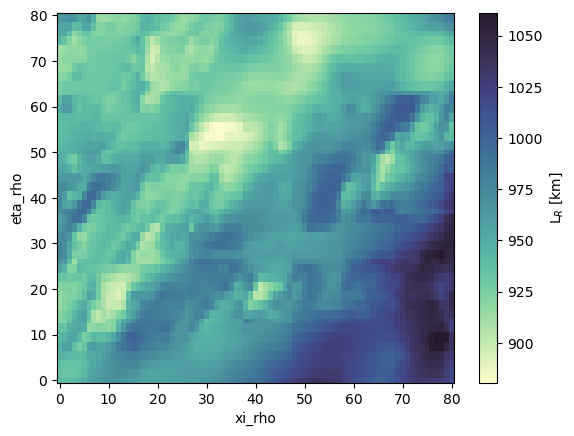

In [30]:
Lr.plot(cmap=cmocean.cm.deep,cbar_kwargs={'label':r'L$_R$ [km]'})


In [ ]:
# Horizontal IW wavelength
lambda_v = 100
omega = 1.01*fc
lanmbda_h = lambda_v*np.sqrt(N/(omega**2-fc**2))